## 1. Prepare bam files

```shell
indir="name_sort_bam"
outdir="deduped_bam"
mkdir -p ${outdir}

rm -f name_sort_bam_to_deduped.sh
for file in `ls ${indir}`; do
    outfile=${file/hisat3n_dna.all_reads.name_sort.bam/bam}
    echo "czip name_sort_bam_to_deduped -I ${indir}/${file} -O ${outdir}/${outfile} --env yap" >> name_sort_bam_to_deduped.sh
done;
cat name_sort_bam_to_deduped.sh | parallel -j 96
```

## 2. Benchmark: `bam_to_cz` vs `bam_to_allc`

Convert every deduped, position-sorted BAM under to both formats and compare **runtime** and **peak memory** per cell:

- `bam_to_allc` (ALLCools) &rarr; `benchmark/allc/<cell>.allc.tsv.gz`
- `bam_to_cz`   (cytozip)  &rarr; `benchmark/cz/<cell>.cz`

Each conversion runs as an isolated subprocess wrapped in `/usr/bin/time -f '%e %M'`
so the reported wall-clock and peak RSS are measured independently. Per-cell metrics
are written to `bam_benchmark.tsv` / `bam_benchmark.txt` and rendered as a grouped
barplot (`bam_benchmark.pdf`, modelled on the one in `2.dnam.ipynb`).

> Set `N_CELLS` in the config cell to a small number (e.g. `24`) for a quick,
> readable per-cell barplot; set it to `None` to process **all** BAM files.


In [1]:
import os,sys
os.chdir(os.path.expanduser("~/Projects/test_cytozip"))

In [2]:
! pwd

/anvil/projects/x-mcb130189/Wubin/test_cytozip


In [ ]:
import os, sys, time, subprocess, random
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd

# ---- paths --------------------------------------------------------------
BAM_DIR  = Path("~/Projects/test_cytozip/deduped_bam").expanduser()
BASE     = Path("~/Projects/test_cytozip/benchmark").expanduser()
ALLC_DIR = BASE / "allc"          # bam_to_allc outputs
CZ_DIR   = BASE / "cz"            # bam_to_cz  outputs
REF_FA   = Path("~/Ref/hg38/hg38_ucsc_with_chrL.fa").expanduser()
REF_CZ   = Path("~/Ref/hg38/hg38_with_chrL.allc.cz").expanduser()
REF_CHROM_SIZE = Path("~/Ref/hg38/hg38_ucsc_with_chrL.main.chrom.sizes").expanduser()
# czip build_ref -g ~/Ref/hg38/hg38_ucsc_with_chrL.fa -O ~/Ref/hg38/hg38_with_chrL.allc.cz -j 24 -s ~/Ref/hg38/hg38_ucsc_with_chrL.main.chrom.sizes

for d in (ALLC_DIR, CZ_DIR, BASE):
    d.mkdir(parents=True, exist_ok=True)

# Srun 4 32 shared 3: 18 CPU 32G
# ---- run parameters -----------------------------------------------------
N_CELLS = 500        # None = ALL bam files; an int randomly samples N cells
SEED    = 0        # RNG seed so the random cell subset is reproducible
JOBS    = 1        # cells processed in parallel (each = 1 allc + 1 cz, serial)

PY       = sys.executable
TIME_BIN = "/usr/bin/time"

# make `samtools` discoverable to child subprocesses (ALLCools shells out to it)
os.environ["PATH"] = str(Path(PY).parent) + os.pathsep + os.environ.get("PATH", "")

bams = sorted(BAM_DIR.glob("*.bam"))
bams = sorted(random.Random(SEED).sample(bams, min(N_CELLS, len(bams))))
bams = bams[:N_CELLS]

assert REF_FA.exists() and Path(str(REF_FA) + ".fai").exists(), "reference FASTA / .fai missing"
assert REF_CZ.exists(), f"reference .cz missing: {REF_CZ}"
print(f"{len(bams)} bam files to benchmark (JOBS={JOBS})")
print(f"  allc -> {ALLC_DIR}")
print(f"  cz   -> {CZ_DIR}")


50 bam files to benchmark (JOBS=1)
  allc -> /home/x-wding2/Projects/test_cytozip/benchmark/allc
  cz   -> /home/x-wding2/Projects/test_cytozip/benchmark/cz


In [4]:
# from ALLCools._bam_to_allc import bam_to_allc
# %time bam_to_allc(bam_path="deduped_bam/UWA7648_CX1819_NAC_1_P10-1-K18-A10.bam", \
#                   reference_fasta=str(REF_FA), \
#                   output_path="UWA7648_CX1819_NAC_1_P10-1-K18-A10.allc.tsv.gz", \
#                   chrom_size=str(REF_CHROM_SIZE),\
#                   cpu=1,num_upstr_bases=0, num_downstr_bases=2, \
#                   min_mapq=10, min_base_quality=20)

# CPU times: user 2min 48s, sys: 11.6 s, total: 3min
# Wall time: 3min 15s

In [5]:
# from cytozip.bam import bam_to_cz
# %time bam_to_cz(bam_path="deduped_bam/UWA7648_CX1819_NAC_1_P10-1-K18-A10.bam", \
#                   genome=str(REF_FA), \
#                   output="UWA7648_CX1819_NAC_1_P10-1-K18-A10.cz", \
#                   reference=str(REF_CZ))

# CPU times: user 1min 18s, sys: 8.86 s, total: 1min 27s
# Wall time: 1min 29s                  

In [4]:
# ---- one isolated call per tool, timed with /usr/bin/time -----------------
_ALLC_CALL = (
    "from ALLCools._bam_to_allc import bam_to_allc; "
    "bam_to_allc(bam_path={bam!r}, reference_fasta={fa!r}, "
    "output_path={out!r}, chrom_size={chrom_size!r}, cpu=1, "
    "num_upstr_bases=0, num_downstr_bases=2, "
    "min_mapq=10, min_base_quality=20, compress_level=5)"
)
_CZ_CALL = (
    "from cytozip.bam import bam_to_cz; "
    "bam_to_cz(bam_path={bam!r}, genome={fa!r}, "
    "output={out!r}, mode='mc_cov', count_fmt='B', reference={ref!r}, "
    "min_mapq=10, min_base_quality=20)"
)


def _time_child(cmd):
    """Run `cmd` under /usr/bin/time; return {ok, wall_s, rss_mb, stderr_tail}."""
    wrapped = [TIME_BIN, "-f", "__TIME__ %e %M", "--"] + list(cmd)
    res = subprocess.run(wrapped, capture_output=True, text=True)
    wall_s, rss_mb = float("nan"), float("nan")
    for line in res.stderr.splitlines()[::-1]:
        if line.startswith("__TIME__"):
            _, w, m = line.split()
            wall_s, rss_mb = float(w), float(m) / 1024.0   # %M is peak RSS in KB
            break
    return dict(ok=res.returncode == 0, wall_s=wall_s, rss_mb=rss_mb,
                stderr_tail="\n".join(res.stderr.splitlines()[-8:]))


# ---- incremental per-cell log (appended the moment each cell finishes) -----
import threading

LOG_TSV = BASE / "bam_benchmark.log.tsv"
_LOG_COLS = ["cell", "bam_size_mb",
             "allc_ok", "allc_wall_s", "allc_rss_mb", "allc_size_mb",
             "cz_ok", "cz_wall_s", "cz_rss_mb", "cz_size_mb"]
_LOG_LOCK = threading.Lock()


def _append_log(row):
    """Thread-safe append of one cell's metrics to LOG_TSV (header written once)."""
    line = "\t".join(str(row.get(c, "")) for c in _LOG_COLS)
    with _LOG_LOCK:
        new = (not LOG_TSV.exists()) or LOG_TSV.stat().st_size == 0
        with open(LOG_TSV, "a") as f:
            if new:
                f.write("\t".join(_LOG_COLS) + "\n")
            f.write(line + "\n")


def _load_log():
    """Load previously logged per-cell metrics as {cell: row_dict} (last wins)."""
    if (not LOG_TSV.exists()) or LOG_TSV.stat().st_size == 0:
        return {}
    prev = pd.read_csv(LOG_TSV, sep="\t")
    return {r["cell"]: r.to_dict() for _, r in prev.iterrows()}


def bench_one(bam_path, prev_log=None):
    """Convert one BAM to allc + cz, timing each conversion in isolation.

    If both output files already exist (non-empty), skip the (re)conversion
    and reuse the previously logged metrics (falling back to on-disk sizes).
    """
    prev_log = prev_log or {}
    bam = Path(bam_path)
    cid = bam.name[:-4]                       # strip trailing ".bam"
    allc_out = ALLC_DIR / f"{cid}.allc.tsv.gz"
    cz_out   = CZ_DIR / f"{cid}.cz"

    # ---- skip if both outputs already exist ----
    if (allc_out.exists() and allc_out.stat().st_size > 0
            and cz_out.exists() and cz_out.stat().st_size > 0):
        row = dict(prev_log.get(cid, {}))
        row.update(cell=cid, bam_size_mb=bam.stat().st_size / 1e6,
                   allc_size_mb=allc_out.stat().st_size / 1e6,
                   cz_size_mb=cz_out.stat().st_size / 1e6)
        row.setdefault("allc_ok", True)
        row.setdefault("cz_ok", True)
        for k in ("allc_wall_s", "allc_rss_mb", "cz_wall_s", "cz_rss_mb"):
            row.setdefault(k, float("nan"))
        row.setdefault("allc_err", "")
        row.setdefault("cz_err", "")
        row["skipped"] = True
        return row

    # ---- run both conversions (start clean so sizes/timings reflect this run) ----
    for p in (allc_out, Path(str(allc_out) + ".tbi"), cz_out):
        if p.exists():
            p.unlink()

    r_a = _time_child([PY, "-c", _ALLC_CALL.format(
        bam=str(bam), fa=str(REF_FA), out=str(allc_out), chrom_size=str(REF_CHROM_SIZE))])
    r_c = _time_child([PY, "-c", _CZ_CALL.format(
        bam=str(bam), fa=str(REF_FA), out=str(cz_out), ref=str(REF_CZ))])

    row = dict(
        cell=cid,
        bam_size_mb=bam.stat().st_size / 1e6,
        allc_ok=r_a["ok"], allc_wall_s=r_a["wall_s"], allc_rss_mb=r_a["rss_mb"],
        allc_size_mb=(allc_out.stat().st_size / 1e6) if allc_out.exists() else 0.0,
        cz_ok=r_c["ok"], cz_wall_s=r_c["wall_s"], cz_rss_mb=r_c["rss_mb"],
        cz_size_mb=(cz_out.stat().st_size / 1e6) if cz_out.exists() else 0.0,
        allc_err=r_a["stderr_tail"], cz_err=r_c["stderr_tail"],
        skipped=False,
    )
    _append_log(row)   # persist this cell's metrics immediately
    return row


In [7]:
# bam_path="deduped_bam/UWA7648_CX1819_NAC_1_P16-1-J7-D14.bam"
# prev_log = _load_log()
# bench_one(bam_path, prev_log=None)

In [8]:
# ---- run the benchmark ----------------------------------------------------
prev_log = _load_log()          # reuse metrics for already-converted cells
t0 = time.perf_counter()
rows = []
with ThreadPoolExecutor(max_workers=JOBS) as ex:
    futs = {ex.submit(bench_one, str(b), prev_log): b for b in bams}
    for i, fut in enumerate(as_completed(futs), 1):
        r = fut.result()
        rows.append(r)
        if r.get("skipped"):
            tag = "SKIP"
        elif r["allc_ok"] and r["cz_ok"]:
            tag = "OK  "
        else:
            tag = "FAIL"
        print(f"[{i:>3}/{len(bams)}] {tag} {r['cell']:<40} "
              f"allc={r['allc_wall_s']:6.1f}s/{r['allc_rss_mb']:6.0f}MB  "
              f"cz={r['cz_wall_s']:6.1f}s/{r['cz_rss_mb']:6.0f}MB", flush=True)
        if tag == "FAIL":
            print("     allc_err:", r["allc_err"][-300:])
            print("     cz_err  :", r["cz_err"][-300:])
print(f"\ntotal wall-clock: {time.perf_counter() - t0:.1f}s")


[  1/50] OK   UWA7648_CX1819_NAC_1_P1-1-I3-E6          allc= 215.4s/   818MB  cz= 110.6s/  1169MB


[  2/50] OK   UWA7648_CX1819_NAC_1_P1-1-I3-N6          allc= 242.9s/   818MB  cz= 104.1s/  1168MB


[  3/50] OK   UWA7648_CX1819_NAC_1_P10-1-K18-F16       allc= 286.7s/   817MB  cz= 117.8s/  1185MB


[  4/50] OK   UWA7648_CX1819_NAC_1_P10-1-K18-J14       allc= 128.7s/   821MB  cz=  75.0s/  1170MB


[  5/50] OK   UWA7648_CX1819_NAC_1_P10-1-K18-P7        allc= 191.9s/   820MB  cz=  91.4s/  1168MB


...

[ 47/50] OK   UWA7648_CX1819_NAC_1_P9-1-M14-A3         allc= 233.7s/   817MB  cz= 104.4s/  1175MB


[ 48/50] OK   UWA7648_CX1819_NAC_1_P9-1-M14-C2         allc= 156.2s/   819MB  cz=  77.3s/  1169MB


[ 49/50] OK   UWA7648_CX1819_NAC_1_P9-1-M14-F24        allc= 239.2s/   817MB  cz= 114.4s/  1168MB


[ 50/50] OK   UWA7648_CX1819_NAC_1_P9-1-M14-J12        allc= 246.2s/   817MB  cz= 108.6s/  1169MB



total wall-clock: 15845.9s


In [9]:
# ---- per-cell table -------------------------------------------------------
LOG_TSV = BASE / "bam_benchmark.log.tsv"
if LOG_TSV.exists() and LOG_TSV.stat().st_size > 0:
    # reuse the incrementally-written per-cell log instead of rebuilding from rows
    df = pd.read_csv(LOG_TSV, sep="\t").sort_values("cell").reset_index(drop=True)
    print("read", LOG_TSV)
else:
    df = pd.DataFrame(sorted(rows, key=lambda r: r["cell"]))
    df = df.drop(columns=["allc_err", "cz_err"], errors="ignore")

df["speedup"]    = df["allc_wall_s"] / df["cz_wall_s"]
df["mem_ratio"]  = df["cz_rss_mb"]   / df["allc_rss_mb"]
df["size_ratio"] = df["cz_size_mb"]  / df["allc_size_mb"]

tsv = BASE / "bam_benchmark.tsv"
df.to_csv(tsv, sep="\t", index=False, float_format="%.4f")
print("wrote", tsv)
df.round(2)

read /home/x-wding2/Projects/test_cytozip/benchmark/bam_benchmark.log.tsv
wrote /home/x-wding2/Projects/test_cytozip/benchmark/bam_benchmark.tsv


,cell,bam_size_mb,allc_ok,allc_wall_s,allc_rss_mb,allc_size_mb,cz_ok,cz_wall_s,cz_rss_mb,cz_size_mb,speedup,mem_ratio,size_ratio
0,UWA7648_CX1819_NAC_1_P1-1-I3-E6,187.66,True,215.40,818.11,108.77,True,110.58,1168.86,24.57,1.95,1.43,0.23
1,UWA7648_CX1819_NAC_1_P1-1-I3-N6,212.62,True,242.94,817.79,121.08,True,104.10,1168.06,25.97,2.33,1.43,0.21
2,UWA7648_CX1819_NAC_1_P10-1-K18-F16,247.00,True,286.70,816.72,141.91,True,117.77,1184.62,29.90,2.43,1.45,0.21
3,UWA7648_CX1819_NAC_1_P10-1-K18-J14,112.31,True,128.69,820.86,64.92,True,75.00,1170.17,16.03,1.72,1.43,0.25
4,UWA7648_CX1819_NAC_1_P10-1-K18-P7,170.29,True,191.88,819.97,98.57,True,91.37,1167.84,22.52,2.10,1.42,0.23
5,UWA7648_CX1819_NAC_1_P11-1-K20-A18,129.51,True,152.19,818.82,74.95,True,96.18,1168.32,17.97,1.58,1.43,0.24
6,UWA7648_CX1819_NAC_1_P11-1-K20-B4,195.62,True,222.26,818.06,113.69,True,113.88,1168.27,25.56,1.95,1.43,0.22
7,UWA7648_CX1819_NAC_1_P11-1-K20-C18,209.34,True,242.04,817.63,120.66,True,105.84,1190.99,25.90,2.29,1.46,0.21
8,UWA7648_CX1819_NAC_1_P11-1-K20-P21,213.50,True,232.03,817.77,122.89,True,105.70,1178.82,26.81,2.20,1.44,0.22
9,UWA7648_CX1819_NAC_1_P11-1-K20-P3,82.08,True,115.70,819.52,47.41,True,64.35,1170.80,12.73,1.80,1.43,0.27


In [10]:
# ---- aggregate summary written to a text file -----------------------------
tot_at, tot_ct = df["allc_wall_s"].sum(), df["cz_wall_s"].sum()
max_arss, max_crss = df["allc_rss_mb"].max(), df["cz_rss_mb"].max()
mean_arss, mean_crss = df["allc_rss_mb"].mean(), df["cz_rss_mb"].mean()
tot_as, tot_cs = df["allc_size_mb"].sum(), df["cz_size_mb"].sum()

txt = BASE / "bam_benchmark.txt"
txt.write_text(
    "cytozip bam_to_cz  vs  ALLCools bam_to_allc\n"
    "============================================\n"
    f"reference FASTA : {REF_FA}\n"
    f"reference .cz   : {REF_CZ}\n"
    f"cells           : {len(df)}\n"
    "\n"
    f"ALLCools : time={tot_at:9.1f} s   peak_rss(max)={max_arss:7.1f} MB   "
    f"mean_rss={mean_arss:7.1f} MB   size={tot_as:8.1f} MB\n"
    f"cytozip  : time={tot_ct:9.1f} s   peak_rss(max)={max_crss:7.1f} MB   "
    f"mean_rss={mean_crss:7.1f} MB   size={tot_cs:8.1f} MB\n"
    "\n"
    f"speedup   (allc / cz  time)      = {tot_at / max(tot_ct, 1e-9):5.2f}x\n"
    f"memory    (cz / allc  mean rss)  = {mean_crss / max(mean_arss, 1e-9) * 100:5.1f}%\n"
    f"compress  (cz / allc  size)      = {tot_cs / max(tot_as, 1e-9) * 100:5.1f}%\n"
)
print(txt.read_text())


cytozip bam_to_cz  vs  ALLCools bam_to_allc
reference FASTA : /home/x-wding2/Ref/hg38/hg38_ucsc_with_chrL.fa
reference .cz   : /home/x-wding2/Ref/hg38/hg38_with_chrL.allc.cz
cells           : 50

ALLCools : time=  10779.7 s   peak_rss(max)=  820.9 MB   mean_rss=  818.1 MB   size=  5568.1 MB
cytozip  : time=   5065.3 s   peak_rss(max)= 1198.9 MB   mean_rss= 1174.0 MB   size=  1238.1 MB

speedup   (allc / cz  time)      =  2.13x
memory    (cz / allc  mean rss)  = 143.5%
compress  (cz / allc  size)      =  22.2%



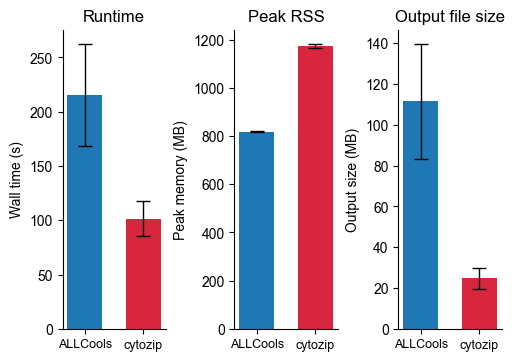

In [11]:
# ---- barplot: average runtime, peak memory & output size (mean +/- SD) -----
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'

d = df.copy()
n = len(d)
c_allc, c_cz = '#1f77b4', '#d7263d'
x = np.arange(2)                       # two tools per panel

metrics = [
    ('allc_wall_s', 'cz_wall_s',  'Wall time (s)',      'Runtime'),
    ('allc_rss_mb', 'cz_rss_mb',  'Peak memory (MB)',   'Peak RSS'),
    ('allc_size_mb', 'cz_size_mb', 'Output size (MB)',  'Output file size'),
]

fig, axes = plt.subplots(1, 3, figsize=(5, 3.5), constrained_layout=True)

for ax, (a_col, c_col, ylabel, title) in zip(axes, metrics):
    means = [d[a_col].mean(), d[c_col].mean()]
    sds   = [d[a_col].std(),  d[c_col].std()]
    ax.bar(x, means, yerr=sds, capsize=5, color=[c_allc, c_cz],
           width=0.6, error_kw=dict(ecolor='black', lw=1))
    ax.set_xticks(x)
    ax.set_xticklabels(['ALLCools', 'cytozip'], fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

tot_at, tot_ct = d['allc_wall_s'].sum(), d['cz_wall_s'].sum()
tot_as, tot_cs = d['allc_size_mb'].sum(), d['cz_size_mb'].sum()
# fig.suptitle(
#     f'BAM \u2192 ALLC vs BAM \u2192 CZ\n(n={n} cells, mean \u00b1 SD)   '
#     f'time: {tot_at:.0f} \u2192 {tot_ct:.0f} s '
#     f'({tot_at / max(tot_ct, 1e-9):.2f}\u00d7 faster)   '
#     f'mean RSS: {d["allc_rss_mb"].mean():.0f} \u2192 {d["cz_rss_mb"].mean():.0f} MB   '
#     f'size: {tot_as:.0f} \u2192 {tot_cs:.0f} MB '
#     f'({tot_cs / max(tot_as, 1e-9) * 100:.1f}%)',
#     fontsize=10,
# )

fig.savefig(BASE / 'bam_benchmark.pdf', bbox_inches='tight')
plt.show()


## 3. Validate: do `allc` and `cz` store the same values?

Load the **entire** `allc` and `cz` files into memory and compare their
`(mc, cov)` values position-by-position. Any inconsistent record is printed.

Comparison rules (matching how each file stores data):

- **cz** is written in `mode='mc_cov'`, so it keeps only `[mc, cov]` aligned
  1:1 with the reference `.cz` positions. We recover coordinates from
  `REF_CZ` and **drop records with `cov == 0`** before comparing.
- **cz** stores counts as `uint8` (`count_fmt='B'`, max 255). Records whose
  **original allc `mc` or `cov` exceeds 255** are **excluded** from the
  comparison (they can't be matched exactly against the truncated cz value).
- ALLCools `bam_to_allc` has a known bug: the **last cytosine of every
  chromosome is dropped**. cz-only sites at each chromosome's last reference
  position are flagged separately (expected, not a real discrepancy).

We merge on `(chrom, pos)` and print every inconsistent record (value
mismatch, allc-only, or real cz-only).


In [ ]:
# ---- helpers to load full allc / cz files for value comparison ------------
import numpy as np
from cytozip.cz import Reader
from cytozip.bam import _LazyRefPositions

# cz stores mc/cov as uint8 ('B'), max 255. We keep the RAW allc values and
# later EXCLUDE any record whose original mc/cov > 255 (can't be compared
# exactly against the truncated cz). cz mode='mc_cov' stores every reference
# position; records with cov == 0 are dropped.
COUNT_MAX = 255


def load_allc(allc_path):
    """Full ALLCools .allc.tsv.gz -> (chrom, pos, mc_allc, cov_allc), raw."""
    return pd.read_csv(
        allc_path, sep="\t", header=None, usecols=[0, 1, 4, 5],
        names=["chrom", "pos", "mc_allc", "cov_allc"],
        dtype={"chrom": str, "pos": np.int64,
               "mc_allc": np.int64, "cov_allc": np.int64},
    )


def load_cz_covered(cz_path, refpos):
    """Full mode='mc_cov' cz -> (chrom, pos, mc_cz, cov_cz), cov>0 only.

    Positions come from the row-aligned reference (`refpos`); records with
    cov == 0 are dropped. Also returns {chrom: last_ref_pos} so the caller
    can recognise the ALLCools "last cytosine of each chromosome is missing"
    bug.
    """
    cell = Reader(str(cz_path))
    frames, last_pos = [], {}
    for dim in cell.chunk_key2offset.keys():
        chrom = dim[-1]
        arr = cell.chunk2numpy(dim)          # f0=mc, f1=cov (uint8)
        mc, cov = arr["f0"], arr["f1"]
        pos = refpos.get(chrom)              # uint32, row-aligned with mc/cov
        if pos is None:
            continue
        if len(pos) != len(mc):
            raise ValueError(
                f"{cz_path} chrom {chrom}: {len(mc)} records but reference "
                f"has {len(pos)} positions (not row-aligned).")
        last_pos[chrom] = int(pos[-1]) if len(pos) else -1
        keep = cov > 0
        frames.append(pd.DataFrame({
            "chrom": chrom,
            "pos": pos[keep].astype(np.int64),
            "mc_cz": mc[keep].astype(np.int64),
            "cov_cz": cov[keep].astype(np.int64),
        }))
        refpos.drop(chrom)                   # release this chrom's ref pages
    cell.close()
    cz = (pd.concat(frames, ignore_index=True) if frames
          else pd.DataFrame(columns=["chrom", "pos", "mc_cz", "cov_cz"]))
    return cz, last_pos


# ---- randomly pick N_COMPARE cell(s) that have BOTH an allc and a cz output
N_COMPARE = 10     # how many cells to compare (whole files loaded in memory)
_paired = [p.name[:-3] for p in sorted(CZ_DIR.glob("*.cz"))
           if (ALLC_DIR / f"{p.name[:-3]}.allc.tsv.gz").exists()]
CMP_CIDS = sorted(random.Random(SEED).sample(_paired, min(N_COMPARE, len(_paired))))
print(f"will compare {len(CMP_CIDS)} cell(s):")
for cid in CMP_CIDS:
    print("  ", cid)


will compare 10 cell(s):
   UWA7648_CX1819_NAC_1_P1-1-I3-E6
   UWA7648_CX1819_NAC_1_P1-1-I3-N6
   UWA7648_CX1819_NAC_1_P10-1-K18-F16
   UWA7648_CX1819_NAC_1_P10-1-K18-J14
   UWA7648_CX1819_NAC_1_P10-1-K18-P7
   UWA7648_CX1819_NAC_1_P11-1-K20-A18
   UWA7648_CX1819_NAC_1_P11-1-K20-B4
   UWA7648_CX1819_NAC_1_P11-1-K20-C18
   UWA7648_CX1819_NAC_1_P11-1-K20-P21
   UWA7648_CX1819_NAC_1_P11-1-K20-P3


In [ ]:
# ---- compare full allc vs cz per cell; print every inconsistent record ----
refpos = _LazyRefPositions(str(REF_CZ))     # streamed uint32 ref positions

for cid in CMP_CIDS:
    a = load_allc(ALLC_DIR / f"{cid}.allc.tsv.gz")          # whole allc
    c, last_pos = load_cz_covered(CZ_DIR / f"{cid}.cz", refpos)  # whole cz (cov>0)

    m = a.merge(c, on=["chrom", "pos"], how="outer", indicator=True)

    # EXCLUDE records affected by uint8 (255) truncation: any allc raw
    # mc/cov > 255 can't be compared exactly against the clipped cz value.
    truncated = ((m["mc_allc"] > COUNT_MAX) | (m["cov_allc"] > COUNT_MAX)).fillna(False)
    n_truncated = int(truncated.sum())
    m = m[~truncated].copy()

    both      = m["_merge"] == "both"
    cz_only   = m["_merge"] == "right_only"     # in cz (cov>0), not in allc
    allc_only = m["_merge"] == "left_only"      # in allc, cz cov==0 or absent

    # value mismatch on shared positions
    val_mis = both & ((m["mc_allc"] != m["mc_cz"]) | (m["cov_allc"] != m["cov_cz"]))

    # cz-only at each chrom's LAST reference position = known ALLCools
    # "drops the last cytosine of every chromosome" bug (not a cz error).
    m["last_pos"] = m["chrom"].map(last_pos)
    cz_only_lastC = cz_only & (m["pos"] == m["last_pos"])

    bad = m[val_mis | allc_only | (cz_only & ~cz_only_lastC)].copy()
    bad["issue"] = np.where(
        bad["_merge"] == "left_only", "allc_only",
        np.where(bad["_merge"] == "right_only", "cz_only", "value_mismatch"))

    print(f"\n===== {cid} =====")
    print(f"  allc records                 : {len(a):,}")
    print(f"  cz covered records (cov>0)   : {len(c):,}")
    print(f"  excluded (mc/cov > 255)      : {n_truncated:,}")
    print(f"  compared shared positions    : {int(both.sum()):,}")
    print(f"  value mismatches             : {int(val_mis.sum()):,}")
    print(f"  allc-only (cz cov==0/absent) : {int(allc_only.sum()):,}")
    print(f"  cz-only (real)               : {int((cz_only & ~cz_only_lastC).sum()):,}")
    print(f"  cz-only (ALLCools last-C bug): {int(cz_only_lastC.sum()):,}")

    if len(bad):
        cols = ["chrom", "pos", "mc_allc", "cov_allc", "mc_cz", "cov_cz", "issue"]
        print(f"\n  --- {len(bad):,} INCONSISTENT records ---")
        with pd.option_context("display.max_rows", None, "display.width", 200):
            print(bad[cols].sort_values(["chrom", "pos"]).to_string(index=False))
    else:
        print("  ✅ FULLY IDENTICAL (excluding 255-truncation & cov==0)")

refpos.close()



===== UWA7648_CX1819_NAC_1_P1-1-I3-E6 =====
  allc records                 : 27,970,275
  cz covered records (cov>0)   : 27,970,275
  excluded (mc/cov > 255)      : 0
  compared shared positions    : 27,970,275
  value mismatches             : 0
  allc-only (cz cov==0/absent) : 0
  cz-only (real)               : 0
  cz-only (ALLCools last-C bug): 0
  ✅ FULLY IDENTICAL (excluding 255-truncation & cov==0)

===== UWA7648_CX1819_NAC_1_P1-1-I3-N6 =====
  allc records                 : 31,524,853
  cz covered records (cov>0)   : 31,524,853
  excluded (mc/cov > 255)      : 0
  compared shared positions    : 31,524,853
  value mismatches             : 0
  allc-only (cz cov==0/absent) : 0
  cz-only (real)               : 0
  cz-only (ALLCools last-C bug): 0
  ✅ FULLY IDENTICAL (excluding 255-truncation & cov==0)

===== UWA7648_CX1819_NAC_1_P10-1-K18-F16 =====
  allc records                 : 36,880,625
  cz covered records (cov>0)   : 36,880,625
  excluded (mc/cov > 255)      : 0
  compared sh